# Supervised ML Pipeline: Predicting Student At-Risk Status

This notebook trains and evaluates a classifier to predict `final_result` (binary classification) using engineered features.

**Target:** `final_result` (1 = Fail/Withdrawn, 0 = Pass/Distinction)

**Reporting only:** `final_result` (not used as feature)


## 0. Setup


In [1]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\Kevin\AppData\Local\Python\pythoncore-3.14-64\python.exe
3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Try to import seaborn, install if missing
try:
    import seaborn as sns
except ImportError:
    print("seaborn not found. Attempting to install...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "--quiet"])
    import seaborn as sns
    print("seaborn installed successfully.")

from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Try to import scikit-learn, install if missing
try:
    from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.dummy import DummyClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.naive_bayes import GaussianNB
    from sklearn.metrics import (
        precision_score, recall_score, f1_score, roc_auc_score,
        confusion_matrix, roc_curve, classification_report
    )
except ImportError:
    print("scikit-learn not found. Attempting to install...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "--quiet"])
    from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.dummy import DummyClassifier
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.naive_bayes import GaussianNB
    from sklearn.metrics import (
        precision_score, recall_score, f1_score, roc_auc_score,
        confusion_matrix, roc_curve, classification_report
    )
    print("scikit-learn installed successfully.")

# Try to import scipy, install if missing
try:
    from scipy.stats import randint, uniform
except ImportError:
    print("scipy not found. Attempting to install...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy", "--quiet"])
    from scipy.stats import randint, uniform
    print("scipy installed successfully.")

# Create directories
os.makedirs('./reports', exist_ok=True)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Setup complete.")


Setup complete.


## 1. Problem framing

### Business Objective
Predict which students are at risk of failing or withdrawing from their course.

### ML Task
- **Type:** Binary classification
- **Target:** `final_result` (1 = at risk, 0 = not at risk)
- **Evaluation:** F1 score (balanced metric for imbalanced classes)

### Success Criteria
- F1 score > baseline (most frequent class)
- Model interpretability for actionable insights
- No data leakage (students not split across train/test)


## 2. Data loading (features file)


In [3]:
# Try parquet first, fallback to CSV
if os.path.exists('./data/encoded_supervised.parquet'):
    df = pd.read_parquet('./data/encoded_supervised.parquet')
    print(f"Loaded from parquet: {df.shape}")
elif os.path.exists('./data/encoded_supervised_major.csv'):
    df = pd.read_csv('./data/encoded_supervised_major.csv')
    print(f"Loaded from CSV: {df.shape}")
else:
    raise FileNotFoundError("Neither ./data/encoded_supervised.parquet nor ./data/encoded_supervised_major.csv found")
print(f"\nColumns ({len(df.columns)}): {list(df.columns)}")
print(f"\nShape: {df.shape}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Loaded from CSV: (32548, 22)

Columns (22): ['id_student', 'highest_education', 'imd_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'avg_clicks_per_day', 'module_presentation_length', 'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count', 'avg_submission_delay', 'sites_revisit_ratio', 'activity_diversity_ratio', 'code_module_BBB', 'code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF', 'code_module_GGG']

Shape: (32548, 22)

Memory usage: 5.49 MB


## 3. Data understanding (EDA + quality checks)


In [4]:
"""
# Basic info
print("=== BASIC INFO ===")
print(f"Shape: {df.shape}")
print(f"\nUnique students: {df['id_student'].nunique()}")
print(f"Unique (student, module, presentation): {df.groupby(['id_student', 'code_module_BBB','code_module_CCC','code_module_DDD','code_module_EEE','code_module_FFF','code_module_GGG']).size().shape[0]}")

# Check for duplicates
duplicates = df.duplicated(subset=['id_student', 'code_module_BBB','code_module_CCC','code_module_DDD','code_module_EEE','code_module_FFF','code_module_GGG','code_presentation_2013J','code_presentation_2014B','code_presentation_2014J']).sum()
print(f"\nDuplicate keys: {duplicates}")
assert duplicates == 0, "Duplicate keys found!"
"""

'\n# Basic info\nprint("=== BASIC INFO ===")\nprint(f"Shape: {df.shape}")\nprint(f"\nUnique students: {df[\'id_student\'].nunique()}")\nprint(f"Unique (student, module, presentation): {df.groupby([\'id_student\', \'code_module_BBB\',\'code_module_CCC\',\'code_module_DDD\',\'code_module_EEE\',\'code_module_FFF\',\'code_module_GGG\']).size().shape[0]}")\n\n# Check for duplicates\nduplicates = df.duplicated(subset=[\'id_student\', \'code_module_BBB\',\'code_module_CCC\',\'code_module_DDD\',\'code_module_EEE\',\'code_module_FFF\',\'code_module_GGG\',\'code_presentation_2013J\',\'code_presentation_2014B\',\'code_presentation_2014J\']).sum()\nprint(f"\nDuplicate keys: {duplicates}")\nassert duplicates == 0, "Duplicate keys found!"\n'

In [5]:

# Target variable distribution
print("=== TARGET VARIABLE ===")
print(f"\nfinal_result distribution:")
print(df['final_result'].value_counts())
print(f"\nfinal_result proportion:")
print(df['final_result'].value_counts(normalize=True))

if 'final_result' in df.columns:
    print(f"\nfinal_result distribution:")
    print(df['final_result'].value_counts())
    print(f"\nCross-tabulation:")
    print(pd.crosstab(df['final_result'], df['final_result'], margins=True))


=== TARGET VARIABLE ===

final_result distribution:
final_result
0.666667    12360
0.000000    10117
0.333333     7047
1.000000     3024
Name: count, dtype: int64

final_result proportion:
final_result
0.666667    0.379747
0.000000    0.310833
0.333333    0.216511
1.000000    0.092909
Name: proportion, dtype: float64

final_result distribution:
final_result
0.666667    12360
0.000000    10117
0.333333     7047
1.000000     3024
Name: count, dtype: int64

Cross-tabulation:
final_result    0.0  0.333333  0.666667   1.0    All
final_result                                        
0.0           10117         0         0     0  10117
0.333333          0      7047         0     0   7047
0.666667          0         0     12360     0  12360
1.0               0         0         0  3024   3024
All           10117      7047     12360  3024  32548


In [6]:
# Missing values
print("=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
print(missing_df)

if len(missing_df) == 0:
    print("\nNo missing values found.")


=== MISSING VALUES ===
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

No missing values found.


In [7]:
# Data types
print("=== DATA TYPES ===")
print(df.dtypes.value_counts())

# Numeric columns summary
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id_student', 'final_result']]
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols[:10]}..." if len(numeric_cols) > 10 else f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in ['id_student', 'code_module', 'code_presentation', 'final_result']]
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols[:10]}..." if len(categorical_cols) > 10 else f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")


=== DATA TYPES ===
float64    14
int64       7
str         1
Name: count, dtype: int64

Numeric columns (19): ['highest_education', 'imd_band', 'num_of_prev_attempts', 'studied_credits', 'date_registration', 'avg_clicks_per_day', 'module_presentation_length', 'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count']...

Categorical columns (1): ['disability']


In [8]:
# Check for leakage: features that directly encode final outcome
print("=== LEAKAGE CHECK ===")
leakage_keywords = ['final', 'result', 'outcome', 'grade', 'overall', 'exam_score', 'total_score']
potential_leakage = []

for col in df.columns:
    if col.lower() in ['final_result', 'final_result']:
        continue
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in leakage_keywords):
        potential_leakage.append(col)

if potential_leakage:
    print(f"\n⚠️  Potential leakage features detected: {potential_leakage}")
    print("\nThese will be excluded from features.")
else:
    print("\n✓ No obvious leakage features detected.")
                                                    

=== LEAKAGE CHECK ===

✓ No obvious leakage features detected.


## 4. Data preparation (preprocessing for ML)


In [9]:
df = df.set_index("id_student")
# Separate target and features
y = (df["final_result"] >= 0.5).astype(int)

# Exclude target, final_result, and key columns from features
# exclude_cols = ['final_result', 'id_student', 'code_module', 'code_presentation']
exclude_cols = ['final_result', 'disability']

# Also exclude potential leakage features
if 'potential_leakage' in locals():
    exclude_cols.extend(potential_leakage)

X = df.drop(columns=[c for c in exclude_cols if c in df.columns])

print(f"Target shape: {y.shape}")
print(f"Features shape: {X.shape}")
print(f"\nExcluded columns: {exclude_cols}")
print(f"\nFeature columns ({len(X.columns)}): {list(X.columns)}")


Target shape: (32548,)
Features shape: (32548, 19)

Excluded columns: ['final_result', 'disability']

Feature columns (19): ['highest_education', 'imd_band', 'num_of_prev_attempts', 'studied_credits', 'date_registration', 'avg_clicks_per_day', 'module_presentation_length', 'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count', 'avg_submission_delay', 'sites_revisit_ratio', 'activity_diversity_ratio', 'code_module_BBB', 'code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF', 'code_module_GGG']


In [10]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# Store feature names for later use
all_feature_names = numeric_features + categorical_features


Numeric features: 19
Categorical features: 0


In [11]:
"""
# Create preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    # ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

print("Preprocessing pipeline created.")
print(f"Numeric transformer: median imputation + StandardScaler")
print(f"Categorical transformer: 'Unknown' imputation + OneHotEncoder (drop='first')")
"""
preprocessor = ColumnTransformer(
    transformers=[],
    remainder='passthrough'
)

## 5. Train/validation/test split (leakage-safe)


In [12]:
"""
# Use GroupShuffleSplit to prevent same student in train/test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Group by id_student
groups = df['id_student'].values

# Split
train_idx, test_idx = next(gss.split(X, y, groups))
"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
"""
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

print(f"\nTrain set unique students: {len(np.unique(groups_train))}")
print(f"Test set unique students: {len(np.unique(groups_test))}")
"""

'\nX_train, X_test = X.iloc[train_idx], X.iloc[test_idx]\ny_train, y_test = y.iloc[train_idx], y.iloc[test_idx]\ngroups_train, groups_test = groups[train_idx], groups[test_idx]\n\nprint(f"Train set: {X_train.shape[0]} samples")\nprint(f"Test set: {X_test.shape[0]} samples")\n\nprint(f"\nTrain set unique students: {len(np.unique(groups_train))}")\nprint(f"Test set unique students: {len(np.unique(groups_test))}")\n'

In [13]:
"""
# Verify no overlap of students between train and test
train_students = set(groups_train)
test_students = set(groups_test)
overlap = train_students.intersection(test_students)

print(f"Train students: {len(train_students)}")
print(f"Test students: {len(test_students)}")
print(f"Overlapping students: {len(overlap)}")

if len(overlap) > 0:
    print(f"\n⚠️  WARNING: Found {len(overlap)} overlapping students!")
    print(f"Sample overlapping IDs: {list(overlap)[:5]}")
else:
    print("\n✓ No student overlap between train and test sets.")
"""

'\n# Verify no overlap of students between train and test\ntrain_students = set(groups_train)\ntest_students = set(groups_test)\noverlap = train_students.intersection(test_students)\n\nprint(f"Train students: {len(train_students)}")\nprint(f"Test students: {len(test_students)}")\nprint(f"Overlapping students: {len(overlap)}")\n\nif len(overlap) > 0:\n    print(f"\n⚠️  WARNING: Found {len(overlap)} overlapping students!")\n    print(f"Sample overlapping IDs: {list(overlap)[:5]}")\nelse:\n    print("\n✓ No student overlap between train and test sets.")\n'

In [14]:
# Check class distribution in splits
print("=== CLASS DISTRIBUTION ===")
print(f"\nTrain set:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set:")
print(y_test.value_counts(normalize=True))

# Note: Stratification with GroupShuffleSplit is limited
# We verify approximate balance instead
train_final_result_pct = y_train.mean() * 100
test_final_result_pct = y_test.mean() * 100
print(f"\nTrain final_result %: {train_final_result_pct:.2f}%")
print(f"Test final_result %: {test_final_result_pct:.2f}%")
print(f"Difference: {abs(train_final_result_pct - test_final_result_pct):.2f}%")

if abs(train_final_result_pct - test_final_result_pct) > 5:
    print("\n⚠️  Note: Class distribution differs >5% between train/test.")


=== CLASS DISTRIBUTION ===

Train set:
final_result
0    0.527345
1    0.472655
Name: proportion, dtype: float64

Test set:
final_result
0    0.527343
1    0.472657
Name: proportion, dtype: float64

Train final_result %: 47.27%
Test final_result %: 47.27%
Difference: 0.00%


## 6. Baseline model


In [15]:
# Baseline 1: DummyClassifier (most frequent)
print("=== BASELINE 1: DummyClassifier (most_frequent) ===")

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_pred_proba_dummy = dummy.predict_proba(X_test)[:, 1]

dummy_accuracy = dummy.score(X_test, y_test)
dummy_precision = precision_score(y_test, y_pred_dummy)
dummy_recall = recall_score(y_test, y_pred_dummy)
dummy_f1 = f1_score(y_test, y_pred_dummy)
dummy_roc_auc = roc_auc_score(y_test, y_pred_proba_dummy)

print(f"Accuracy: {dummy_accuracy:.4f}")
print(f"Precision: {dummy_precision:.4f}")
print(f"Recall: {dummy_recall:.4f}")
print(f"F1: {dummy_f1:.4f}")
print(f"ROC-AUC: {dummy_roc_auc:.4f}")


=== BASELINE 1: DummyClassifier (most_frequent) ===
Accuracy: 0.5273
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
ROC-AUC: 0.5000


In [16]:
# Baseline 2: DummyClassifier (stratified)
print("=== BASELINE 2: DummyClassifier (stratified) ===")

dummy2 = DummyClassifier(strategy='stratified', random_state=42)
dummy2.fit(X_train, y_train)

y_pred_dummy2 = dummy2.predict(X_test)
y_pred_proba_dummy2 = dummy2.predict_proba(X_test)[:, 1]

dummy_accuracy2 = dummy2.score(X_test, y_test)
dummy_precision2 = precision_score(y_test, y_pred_dummy2)
dummy_recall2 = recall_score(y_test, y_pred_dummy2)
dummy_f12 = f1_score(y_test, y_pred_dummy2)
dummy_roc_auc2 = roc_auc_score(y_test, y_pred_proba_dummy2)

print(f"Accuracy: {dummy_accuracy2:.4f}")
print(f"Precision: {dummy_precision2:.4f}")
print(f"Recall: {dummy_recall2:.4f}")
print(f"F1: {dummy_f12:.4f}")
print(f"ROC-AUC: {dummy_roc_auc2:.4f}")


=== BASELINE 2: DummyClassifier (stratified) ===
Accuracy: 0.5018
Precision: 0.4729
Recall: 0.4709
F1: 0.4719
ROC-AUC: 0.5002


## 7. Main model


In [17]:
# LogisticRegression with RFECV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

print("=== MAIN MODEL: LogisticRegression with RFECV ===")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=2000, solver="liblinear"),
    step=1,
    cv=cv,
    scoring="f1",
    min_features_to_select=5,
    n_jobs=-1
)

pipe_rfecv_logreg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("rfecv", rfecv),
    ("classifier", LogisticRegression(max_iter=2000, solver="liblinear")),
])

pipe_rfecv_logreg.fit(X_train, y_train)

print("Selected # of features:", pipe_rfecv_logreg.named_steps["rfecv"].n_features_)

y_pred_lr = pipe_rfecv_logreg.predict(X_test)
y_pred_proba_lr = pipe_rfecv_logreg.predict_proba(X_test)[:, 1]

lr_accuracy = pipe_rfecv_logreg.score(X_test, y_test)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_pred_proba_lr)

print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"F1: {lr_f1:.4f}")
print(f"ROC-AUC: {lr_roc_auc:.4f}")


=== MAIN MODEL: LogisticRegression with RFECV ===
Selected # of features: 19
Accuracy: 0.9157
Precision: 0.8938
Recall: 0.9324
F1: 0.9127
ROC-AUC: 0.9706


In [18]:
# Main model: RandomForestClassifier with RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold


print("=== MAIN MODEL: RandomForestClassifier ===")

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1))
])

# Hyperparameter search space (small, fast search)
param_distributions = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_split': randint(2, 10),
    'classifier__min_samples_leaf': randint(1, 5)
}

# Use GroupShuffleSplit for cross-validation to prevent leakage
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions,
    n_iter=20,  # Small search space
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting hyperparameter search...")
random_search.fit(X_train, y_train)

print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best CV F1 score: {random_search.best_score_:.4f}")


=== MAIN MODEL: RandomForestClassifier ===
Starting hyperparameter search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 9, 'classifier__n_estimators': 181}
Best CV F1 score: 0.9290


In [19]:
# Evaluate best model on test set
best_model = random_search.best_estimator_

y_pred_rf = best_model.predict(X_test)
y_pred_proba_rf = best_model.predict_proba(X_test)[:, 1]

rf_accuracy = best_model.score(X_test, y_test)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print(f"=== TEST SET RESULTS ===")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1: {rf_f1:.4f}")
print(f"ROC-AUC: {rf_roc_auc:.4f}")


=== TEST SET RESULTS ===
Accuracy: 0.9309
Precision: 0.8955
Recall: 0.9665
F1: 0.9297
ROC-AUC: 0.9778


## 7. Additional Models


In [20]:
# Train and evaluate DecisionTreeClassifier
print("=== DECISION TREE CLASSIFIER ===")

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=20))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)
y_pred_proba_dt = dt_pipeline.predict_proba(X_test)[:, 1]

dt_accuracy = dt_pipeline.score(X_test, y_test)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_pred_proba_dt)

print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1: {dt_f1:.4f}")
print(f"ROC-AUC: {dt_roc_auc:.4f}")


=== DECISION TREE CLASSIFIER ===
Accuracy: 0.9018
Precision: 0.8942
Recall: 0.8986
F1: 0.8964
ROC-AUC: 0.9064


In [21]:
# Train and evaluate GaussianNB
print("=== GAUSSIAN NAIVE BAYES ===")

# Note: GaussianNB works better with scaled features, which are already included in preprocessor
nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

nb_pipeline.fit(X_train, y_train)

y_pred_nb = nb_pipeline.predict(X_test)
y_pred_proba_nb = nb_pipeline.predict_proba(X_test)[:, 1]

nb_accuracy = nb_pipeline.score(X_test, y_test)
nb_precision = precision_score(y_test, y_pred_nb)
nb_recall = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
nb_roc_auc = roc_auc_score(y_test, y_pred_proba_nb)

print(f"Accuracy: {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1: {nb_f1:.4f}")
print(f"ROC-AUC: {nb_roc_auc:.4f}")


=== GAUSSIAN NAIVE BAYES ===
Accuracy: 0.8972
Precision: 0.8470
Recall: 0.9552
F1: 0.8978
ROC-AUC: 0.9585


In [22]:
# Train and evaluate GradientBoostingClassifier
print("=== GRADIENT BOOSTING CLASSIFIER ===")

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=5))
])

gb_pipeline.fit(X_train, y_train)

y_pred_gb = gb_pipeline.predict(X_test)
y_pred_proba_gb = gb_pipeline.predict_proba(X_test)[:, 1]

gb_accuracy = gb_pipeline.score(X_test, y_test)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_roc_auc = roc_auc_score(y_test, y_pred_proba_gb)

print(f"Accuracy: {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall: {gb_recall:.4f}")
print(f"F1: {gb_f1:.4f}")
print(f"ROC-AUC: {gb_roc_auc:.4f}")


=== GRADIENT BOOSTING CLASSIFIER ===
Accuracy: 0.9292
Precision: 0.8983
Recall: 0.9587
F1: 0.9275
ROC-AUC: 0.9770


## 8. Evaluation


In [23]:
# Create metrics comparison table
metrics_df = pd.DataFrame({
    'Model': ['Dummy (most_frequent)', 'Dummy (stratified)', 'LogisticRegression with RFECV', 'RandomForest (tuned)', 
              'DecisionTreeClassifier', 'GaussianNB', 'GradientBoostingClassifier'],
    'Accuracy': [dummy_accuracy, dummy_accuracy2, lr_accuracy, rf_accuracy, 
                  dt_accuracy, nb_accuracy, gb_accuracy],
    'Precision': [dummy_precision, dummy_precision2, lr_precision, rf_precision, 
                  dt_precision, nb_precision, gb_precision],
    'Recall': [dummy_recall, dummy_recall2, lr_recall, rf_recall, 
               dt_recall, nb_recall, gb_recall],
    'F1': [dummy_f1, dummy_f12, lr_f1, rf_f1, 
           dt_f1, nb_f1, gb_f1],
    'ROC-AUC': [dummy_roc_auc, dummy_roc_auc2, lr_roc_auc, rf_roc_auc, 
                dt_roc_auc, nb_roc_auc, gb_roc_auc]
})

print("=== METRICS COMPARISON ===")
print(metrics_df.to_string(index=False))

# Save metrics
metrics_df.to_csv('./reports/metrics.csv', index=False)
print("\nSaved: ./reports/metrics.csv")


=== METRICS COMPARISON ===
                        Model  Accuracy  Precision   Recall       F1  ROC-AUC
        Dummy (most_frequent)  0.527343   0.000000 0.000000 0.000000 0.500000
           Dummy (stratified)  0.501843   0.472911 0.470913 0.471910 0.500240
LogisticRegression with RFECV  0.915668   0.893769 0.932402 0.912677 0.970587
         RandomForest (tuned)  0.930876   0.895513 0.966526 0.929666 0.977758
       DecisionTreeClassifier  0.901843   0.894243 0.898603 0.896418 0.906416
                   GaussianNB  0.897235   0.846974 0.955151 0.897816 0.958486
   GradientBoostingClassifier  0.929186   0.898295 0.958726 0.927527 0.976990

Saved: ./reports/metrics.csv


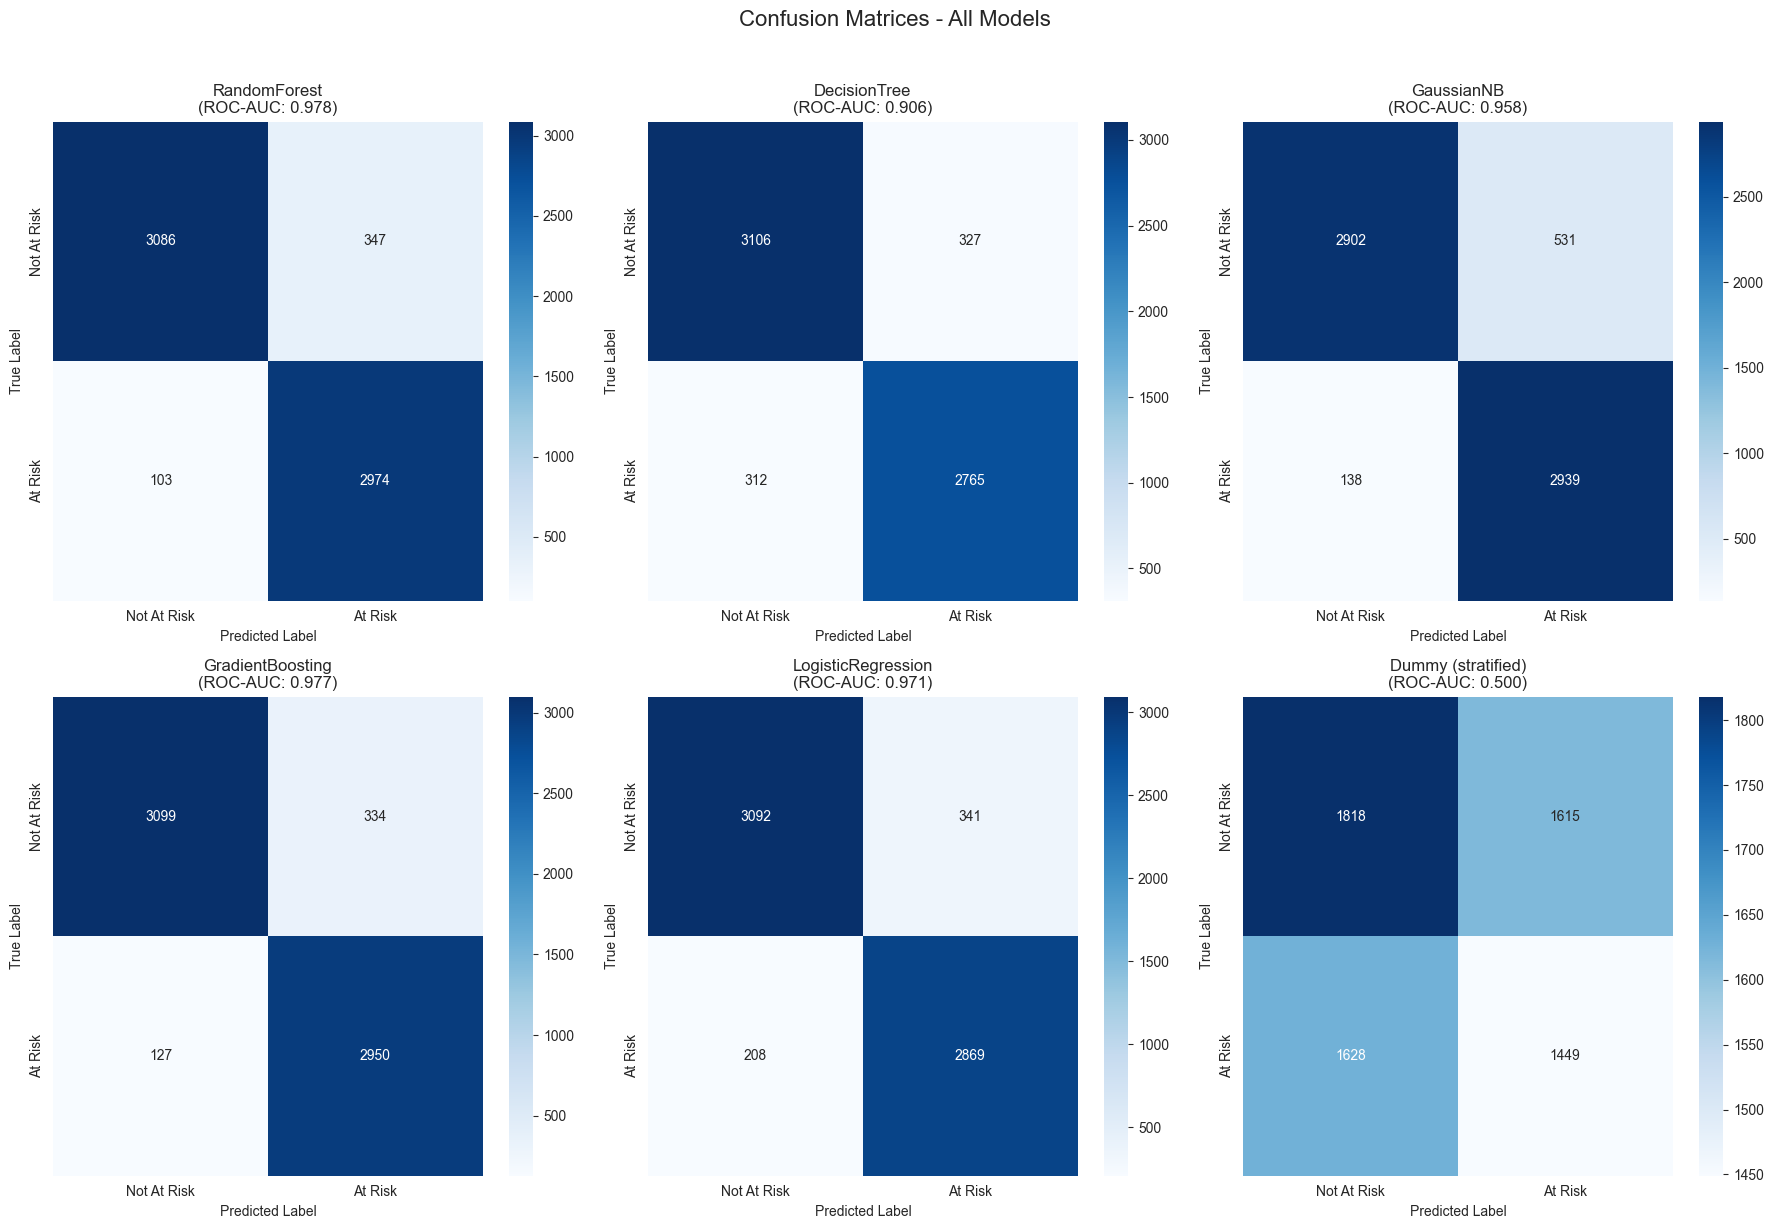

Saved: ./reports/confusion_matrix.png


In [24]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, y=1.02)

models_conf = [
    ('RandomForest', y_pred_rf, rf_roc_auc),
    ('DecisionTree', y_pred_dt, dt_roc_auc),
    ('GaussianNB', y_pred_nb, nb_roc_auc),
    ('GradientBoosting', y_pred_gb, gb_roc_auc),
    ('LogisticRegression', y_pred_lr, lr_roc_auc),
    ('Dummy (stratified)', y_pred_dummy2, dummy_roc_auc2)
]

for idx, (name, y_pred, roc_auc) in enumerate(models_conf):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not At Risk', 'At Risk'],
                yticklabels=['Not At Risk', 'At Risk'])
    ax.set_title(f'{name}\n(ROC-AUC: {roc_auc:.3f})')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('./reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./reports/confusion_matrix.png")


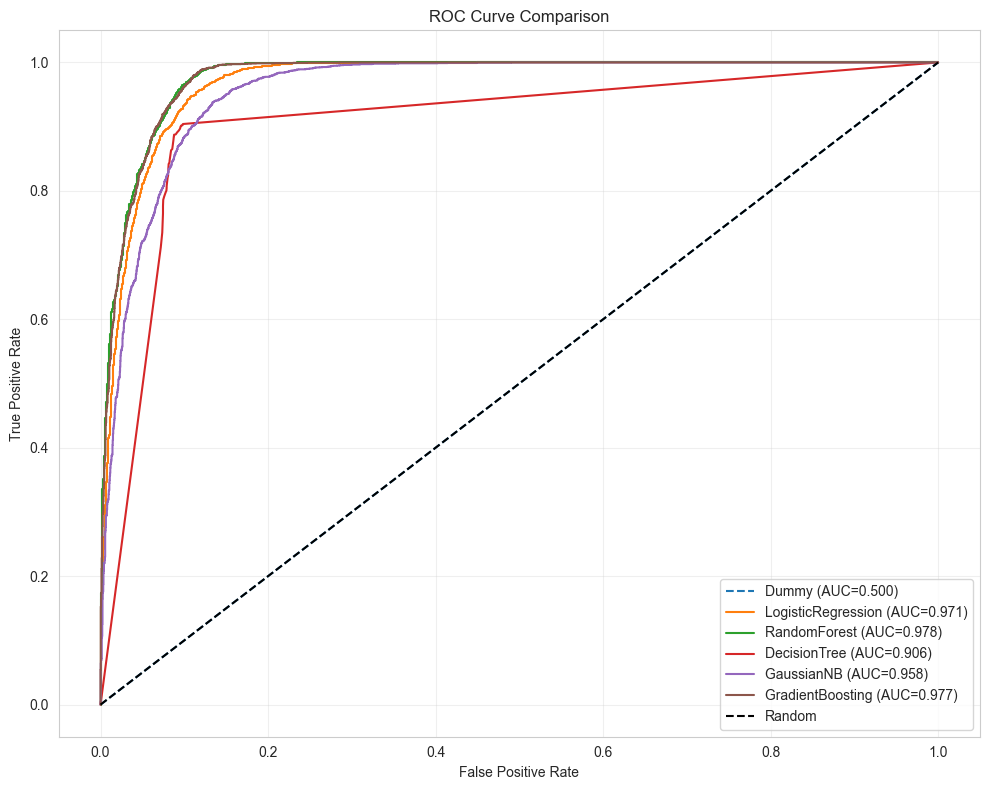

Saved: ./reports/roc_curve.png


In [25]:
# ROC curve comparison
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_pred_proba_dummy)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_proba_nb)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb)

plt.figure(figsize=(10, 8))
plt.plot(fpr_dummy, tpr_dummy, label=f'Dummy (AUC={dummy_roc_auc:.3f})', linestyle='--')
plt.plot(fpr_lr, tpr_lr, label=f'LogisticRegression (AUC={lr_roc_auc:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC={rf_roc_auc:.3f})')
plt.plot(fpr_dt, tpr_dt, label=f'DecisionTree (AUC={dt_roc_auc:.3f})')
plt.plot(fpr_nb, tpr_nb, label=f'GaussianNB (AUC={nb_roc_auc:.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'GradientBoosting (AUC={gb_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./reports/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./reports/roc_curve.png")


## 9. Interpretability


In [26]:
""" 
# LogisticRegression coefficients
print("=== LOGISTIC REGRESSION: TOP COEFFICIENTS ===")

# Get feature names from OneHotEncoder
lr_preprocessor = lr_pipeline.named_steps['preprocessor']
lr_classifier = lr_pipeline.named_steps['classifier']

# Get feature names
feature_names = []

# Numeric features
feature_names.extend(numeric_features)

# Categorical features (from OneHotEncoder)
cat_transformer = lr_preprocessor.named_transformers_['cat']
onehot = cat_transformer.named_steps['onehot']
cat_feature_names = onehot.get_feature_names_out(categorical_features)
feature_names.extend(cat_feature_names)

# Get coefficients
coefficients = lr_classifier.coef_[0]

# Create DataFrame
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})
"""

print("=== LOGISTIC REGRESSION: TOP COEFFICIENTS (after RFECV) ===")

rfecv = pipe_rfecv_logreg.named_steps["rfecv"]
lr = pipe_rfecv_logreg.named_steps["classifier"]

all_feature_names = X_train.columns.to_list()

# only keep selected features
selected_mask = rfecv.support_
selected_feature_names = [f for f, keep in zip(all_feature_names, selected_mask) if keep]

# coefficients representing selected features
coef = lr.coef_.ravel()

# sanity check
assert len(selected_feature_names) == len(coef), (
    f"Mismatch: {len(selected_feature_names)} selected features vs {len(coef)} coefficients"
)

coef_df = pd.DataFrame({
    "feature": selected_feature_names,
    "coefficient": coef
})

print(coef_df.head(15))

# Sort by absolute value
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print("\nTop 10 positive coefficients (increase final_result probability):")
print(coef_df[coef_df['coefficient'] > 0].head(10)[['feature', 'coefficient']].to_string(index=False))

print("\nTop 10 negative coefficients (decrease final_result probability):")
print(coef_df[coef_df['coefficient'] < 0].head(10)[['feature', 'coefficient']].to_string(index=False))


=== LOGISTIC REGRESSION: TOP COEFFICIENTS (after RFECV) ===
                       feature  coefficient
0            highest_education     0.868471
1                     imd_band     0.312044
2         num_of_prev_attempts     0.000745
3              studied_credits     0.042323
4            date_registration    -0.006493
5           avg_clicks_per_day     0.118510
6   module_presentation_length     0.147306
7       tma_cma_weighted_score     6.648681
8            total_submissions     3.357423
9       late_submissions_count    -0.517751
10        avg_submission_delay     0.020714
11         sites_revisit_ratio     0.101369
12    activity_diversity_ratio     1.353415
13             code_module_BBB    -0.372106
14             code_module_CCC     0.184497

Top 10 positive coefficients (increase final_result probability):
                   feature  coefficient
    tma_cma_weighted_score     6.648681
         total_submissions     3.357423
           code_module_GGG     2.727707
  activit

In [27]:
"""
# Feature importances for tree-based models
print("=== FEATURE IMPORTANCES ===")

# Helper function to get feature names from preprocessor
def get_feature_names(model_pipeline):
    preprocessor = model_pipeline.named_steps['preprocessor']
    feature_names = []
    feature_names.extend(numeric_features)
    
    cat_transformer = preprocessor.named_transformers_['cat']
    onehot = cat_transformer.named_steps['onehot']
    cat_feature_names = onehot.get_feature_names_out(categorical_features)
    feature_names.extend(cat_feature_names)
    return feature_names

# RandomForest feature importances
print("\n=== RANDOM FOREST ===")
rf_feature_names = get_feature_names(best_model)
rf_importances = best_model.named_steps['classifier'].feature_importances_
rf_importance_df = pd.DataFrame({
    'feature': rf_feature_names,
    'importance': rf_importances
}).sort_values('importance', ascending=False)
print("\nTop 10 most important features:")
print(rf_importance_df.head(10).to_string(index=False))

# DecisionTree feature importances
print("\n=== DECISION TREE ===")
dt_feature_names = get_feature_names(dt_pipeline)
dt_importances = dt_pipeline.named_steps['classifier'].feature_importances_
dt_importance_df = pd.DataFrame({
    'feature': dt_feature_names,
    'importance': dt_importances
}).sort_values('importance', ascending=False)
print("\nTop 10 most important features:")
print(dt_importance_df.head(10).to_string(index=False))

# GradientBoosting feature importances
print("\n=== GRADIENT BOOSTING ===")
gb_feature_names = get_feature_names(gb_pipeline)
gb_importances = gb_pipeline.named_steps['classifier'].feature_importances_
gb_importance_df = pd.DataFrame({
    'feature': gb_feature_names,
    'importance': gb_importances
}).sort_values('importance', ascending=False)
print("\nTop 10 most important features:")
print(gb_importance_df.head(10).to_string(index=False))

# Note: GaussianNB doesn't have feature_importances_ attribute
print("\nNote: GaussianNB is a probabilistic model and doesn't provide feature importances.")
"""

print("=== FEATURE IMPORTANCES ===")

def get_feature_names_after_selection(model_pipeline, X_ref):
    feature_names = X_ref.columns.to_list()
    return feature_names

def print_tree_importances(pipeline, X_ref, title, top_n=10):
    clf = pipeline.named_steps["classifier"]
    if not hasattr(clf, "feature_importances_"):
        print(f"\n=== {title} ===")
        print("This model does not provide feature_importances_.")
        return

    feature_names = get_feature_names_after_selection(pipeline, X_ref)
    importances = clf.feature_importances_

    # sanity check
    if len(feature_names) != len(importances):
        raise ValueError(
            f"[{title}] Mismatch: {len(feature_names)} feature names vs "
            f"{len(importances)} importances. "
            "You likely applied selection but did not filter names correctly."
        )

    df_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print(f"\n=== {title} ===")
    print(f"Top {top_n} most important features:")
    print(df_imp.head(top_n).to_string(index=False))
    return df_imp

# RandomForest
rf_importance_df = print_tree_importances(best_model, X_train, "RANDOM FOREST", top_n=10)

# DecisionTree
dt_importance_df = print_tree_importances(dt_pipeline, X_train, "DECISION TREE", top_n=10)

# GradientBoosting
gb_importance_df = print_tree_importances(gb_pipeline, X_train, "GRADIENT BOOSTING", top_n=10)

print("\nNote: GaussianNB is a probabilistic model and doesn't provide feature_importances_.")



=== FEATURE IMPORTANCES ===

=== RANDOM FOREST ===
Top 10 most important features:
                 feature  importance
       total_submissions    0.295043
  tma_cma_weighted_score    0.282973
activity_diversity_ratio    0.149826
     sites_revisit_ratio    0.065464
    avg_submission_delay    0.062477
      avg_clicks_per_day    0.034947
  late_submissions_count    0.028721
       date_registration    0.013677
         code_module_GGG    0.010615
         studied_credits    0.010293

=== DECISION TREE ===
Top 10 most important features:
                 feature  importance
       total_submissions    0.609024
  tma_cma_weighted_score    0.164893
         code_module_GGG    0.036255
    avg_submission_delay    0.035115
activity_diversity_ratio    0.030298
      avg_clicks_per_day    0.022536
     sites_revisit_ratio    0.021028
       date_registration    0.018437
         code_module_CCC    0.015269
  late_submissions_count    0.011455

=== GRADIENT BOOSTING ===
Top 10 most important

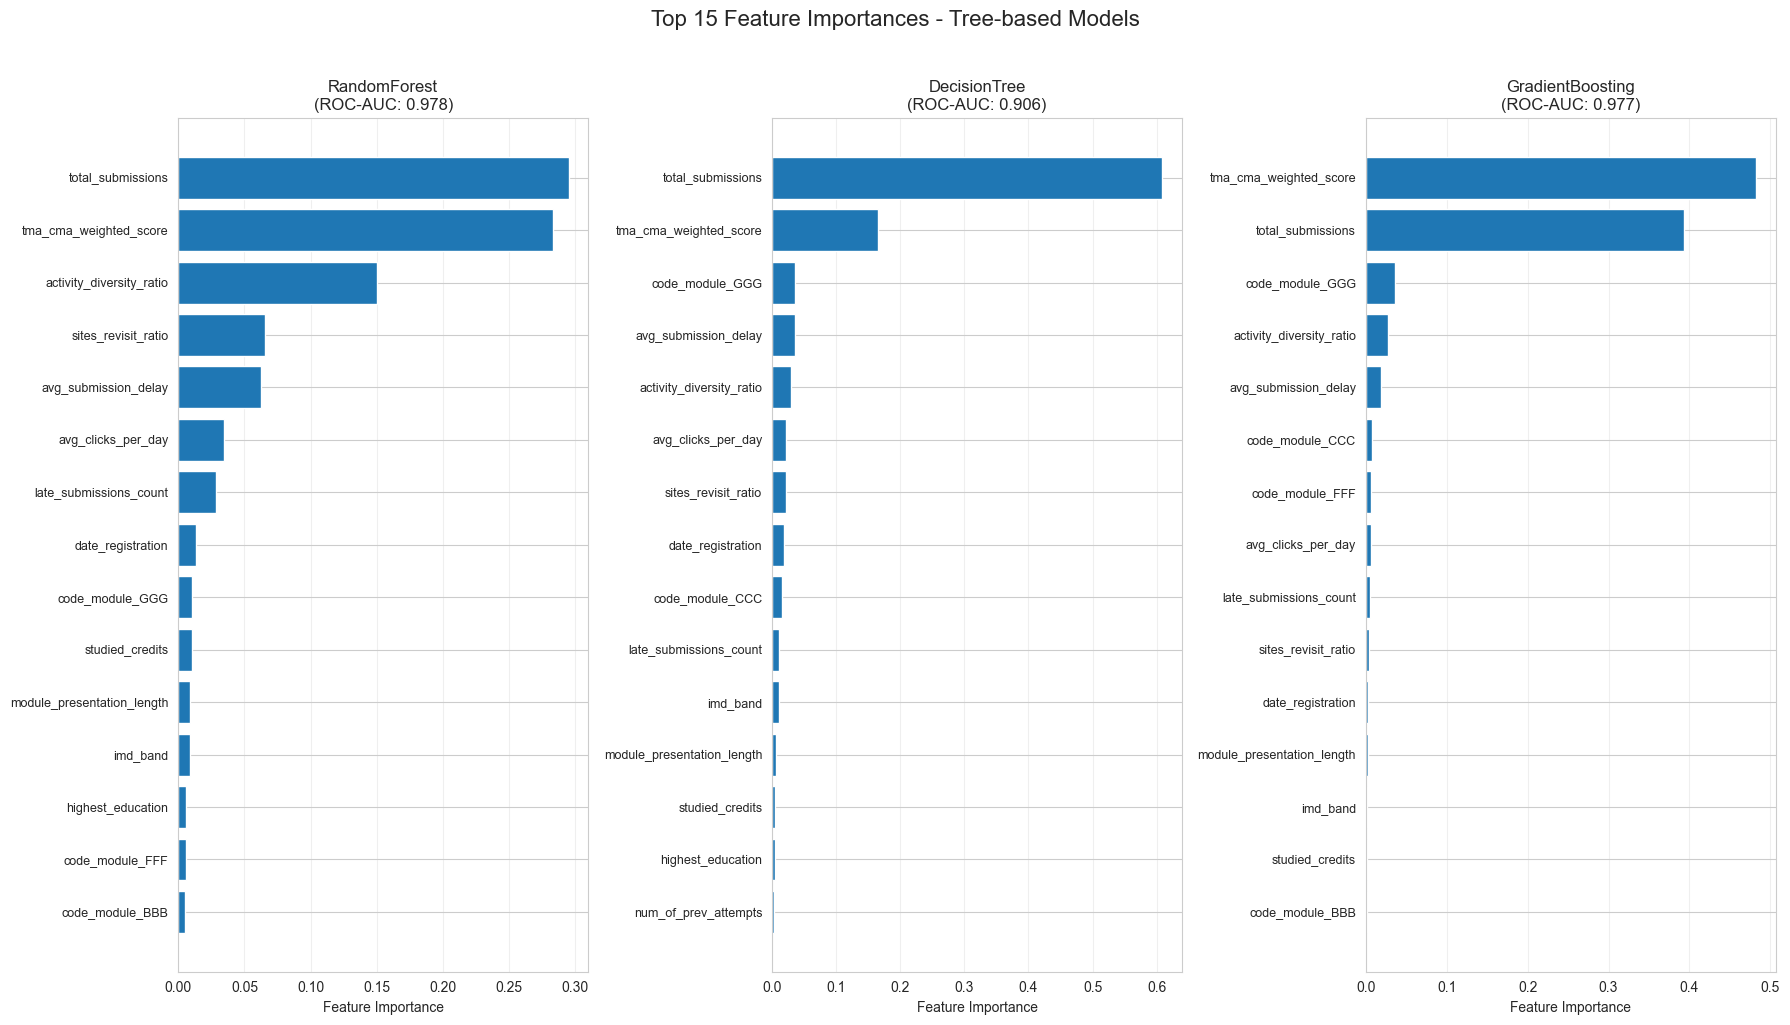

Saved: ./reports/feature_importance.png


In [28]:
# Plot feature importances for all tree-based models
top_n = 15
fig, axes = plt.subplots(1, 3, figsize=(18, 10))
fig.suptitle(f'Top {top_n} Feature Importances - Tree-based Models', fontsize=16, y=1.02)

models_importance = [
    ('RandomForest', rf_importance_df, rf_roc_auc),
    ('DecisionTree', dt_importance_df, dt_roc_auc),
    ('GradientBoosting', gb_importance_df, gb_roc_auc)
]

for idx, (name, importance_df, roc_auc) in enumerate(models_importance):
    ax = axes[idx]
    top_features = importance_df.head(top_n)
    
    ax.barh(range(len(top_features)), top_features['importance'].values)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'].values, fontsize=9)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{name}\n(ROC-AUC: {roc_auc:.3f})')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('./reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ./reports/feature_importance.png")


## 10. Error analysis


In [29]:
# Create error analysis DataFrame
train_idx = X_train.index
test_idx  = X_test.index
error_df = X_test.copy()
error_df["id_student"] = error_df.index
error_df["final_result"] = y_test.values
error_df['y_true'] = y_test.values
error_df['y_pred_rf'] = y_pred_rf
error_df['y_pred_proba_rf'] = y_pred_proba_rf
error_df['y_pred_lr'] = y_pred_lr
error_df['y_pred_proba_lr'] = y_pred_proba_lr

# Identify errors
error_df['error_type'] = 'Correct'
error_df.loc[(error_df['y_true'] == 1) & (error_df['y_pred_rf'] == 0), 'error_type'] = 'False Negative'
error_df.loc[(error_df['y_true'] == 0) & (error_df['y_pred_rf'] == 1), 'error_type'] = 'False Positive'

print(f"=== ERROR SUMMARY ===")
print(error_df['error_type'].value_counts())
print(f"\nFalse Negative Rate: {(error_df['error_type'] == 'False Negative').sum() / (y_test == 1).sum() * 100:.2f}%")
print(f"False Positive Rate: {(error_df['error_type'] == 'False Positive').sum() / (y_test == 0).sum() * 100:.2f}%")

error_df.head()


=== ERROR SUMMARY ===
error_type
Correct           6060
False Positive     347
False Negative     103
Name: count, dtype: int64

False Negative Rate: 3.35%
False Positive Rate: 10.11%


,highest_education,imd_band,num_of_prev_attempts,studied_credits,date_registration,avg_clicks_per_day,module_presentation_length,tma_cma_weighted_score,total_submissions,late_submissions_count,avg_submission_delay,sites_revisit_ratio,activity_diversity_ratio,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,id_student,final_result,y_true,y_pred_rf,y_pred_proba_rf,y_pred_lr,y_pred_proba_lr,error_type
id_student,,,,,,,,,,,,,,,,,,,,,,,,,,,
649351,0.25,0.777778,-0.368196,0.0,-1.859300,-1.484743,0.453958,0.00000,-0.625,-0.828366,0.000000,-1.321984,-0.683180,1,0,0,0,0,0,649351,0,0,0,0.000000,0,0.001709,Correct
174512,0.25,1.000000,-0.368196,0.0,-2.102907,-1.484743,-1.139701,0.00000,-0.625,-0.828366,0.000000,-1.321984,-0.683180,0,0,0,1,0,0,174512,0,0,0,0.000000,0,0.000650,Correct
591620,0.50,0.444444,-0.368196,1.0,-0.620967,-1.484743,0.909289,0.00000,-0.625,-0.828366,0.000000,-1.321984,-0.683180,0,0,0,0,1,0,591620,0,0,0,0.000000,0,0.000214,Correct
336014,0.75,0.888889,-0.368196,1.0,0.840672,0.028796,0.985178,0.36140,-0.125,0.651325,0.105705,0.133424,0.150291,0,1,0,0,0,0,336014,0,0,0,0.129329,0,0.384890,Correct
150578,0.25,0.666667,-0.368196,0.0,-0.823973,-0.408832,-1.215590,0.10715,-0.125,1.038796,0.369966,-0.327226,0.317510,0,0,1,0,0,0,150578,0,0,0,0.033228,0,0.012623,Correct


In [30]:
# Top 20 False Negatives (predicted not at risk, but actually at risk)
print("=== TOP 20 FALSE NEGATIVES (Logistic Regression) ===")
fn_lr = error_df[error_df['error_type'] == 'False Negative'].copy()
fn_lr = fn_lr.sort_values('y_pred_proba_lr', ascending=True)  # Lowest predicted probability

# Select key columns for display
display_cols = ['id_student', 'final_result', 'y_pred_proba_lr']
# display_cols = ['final_result', 'y_pred_proba']
# Add a few feature columns if they exist
if 'mean_score' in fn_lr.columns:
    display_cols.append('mean_score')
if 'total_clicks' in fn_lr.columns:
    display_cols.append('total_clicks')

print(fn_lr[display_cols].head(20).to_string(index=False))

=== TOP 20 FALSE NEGATIVES (Logistic Regression) ===
 id_student  final_result  y_pred_proba_lr
     608472             1         0.007811
     478069             1         0.018818
     590676             1         0.038743
     610279             1         0.056068
     532531             1         0.080964
     574347             1         0.085046
     612187             1         0.095369
     559518             1         0.105257
     369208             1         0.120126
     340010             1         0.126699
     291805             1         0.136028
    2611371             1         0.141610
     649949             1         0.150107
     992544             1         0.157163
     259951             1         0.161580
     532718             1         0.172815
     385927             1         0.178117
     595079             1         0.185332
     651561             1         0.186448
     647083             1         0.189748


In [31]:
# Top 20 False Positives (predicted at risk, but actually not at risk)
print("=== TOP 20 FALSE POSITIVES (Logistic Regression) ===")
fp_lr = error_df[error_df['error_type'] == 'False Positive'].copy()
fp_lr = fp_lr.sort_values('y_pred_proba_lr', ascending=False)  # Highest predicted probability

print(fp_lr[display_cols].head(20).to_string(index=False))

=== TOP 20 FALSE POSITIVES (Logistic Regression) ===
 id_student  final_result  y_pred_proba_lr
     645770             0         0.993869
     631655             0         0.991569
     532695             0         0.988761
     628029             0         0.988222
     520588             0         0.986274
     305935             0         0.985572
    1577134             0         0.985002
     559612             0         0.984384
     528846             0         0.982938
      81351             0         0.982726
     624060             0         0.982422
     539514             0         0.981562
     473491             0         0.980324
     151917             0         0.979461
    1722493             0         0.979392
     446397             0         0.978610
     269575             0         0.978491
     605367             0         0.977936
     498828             0         0.974795
     549922             0         0.974534


In [32]:
# Top 20 False Negatives (predicted not at risk, but actually at risk)
print("=== TOP 20 FALSE NEGATIVES (Random Forest) ===")
fn_rf = error_df[error_df['error_type'] == 'False Negative'].copy()
fn_rf = fn_rf.sort_values('y_pred_proba_rf', ascending=True)  # Lowest predicted probability

# Select key columns for display
display_cols = ['id_student', 'final_result', 'y_pred_proba_rf']
# display_cols = ['final_result', 'y_pred_proba']
# Add a few feature columns if they exist
if 'mean_score' in fn_rf.columns:
    display_cols.append('mean_score')
if 'total_clicks' in fn_rf.columns:
    display_cols.append('total_clicks')

print(fn_rf[display_cols].head(20).to_string(index=False))


=== TOP 20 FALSE NEGATIVES (Random Forest) ===
 id_student  final_result  y_pred_proba_rf
     608472             1         0.036611
     478069             1         0.073021
     647083             1         0.087807
     601706             1         0.103991
     574347             1         0.111824
     609932             1         0.129090
     532739             1         0.130760
     604571             1         0.168152
     291805             1         0.174907
     651209             1         0.211200
     473095             1         0.213402
     532531             1         0.217849
     627685             1         0.223561
     497088             1         0.257547
     545704             1         0.257620
    2092834             1         0.266868
     651027             1         0.267721
     627100             1         0.274315
      87107             1         0.276164
     491170             1         0.280404


In [33]:
# Top 20 False Positives (predicted at risk, but actually not at risk)
print("=== TOP 20 FALSE POSITIVES (Random Forest) ===")
fp_rf = error_df[error_df['error_type'] == 'False Positive'].copy()
fp_rf = fp_rf.sort_values('y_pred_proba_rf', ascending=False)  # Highest predicted probability

print(fp_rf[display_cols].head(20).to_string(index=False))

=== TOP 20 FALSE POSITIVES (Random Forest) ===
 id_student  final_result  y_pred_proba_rf
     584718             0         0.993679
     549922             0         0.990674
     498828             0         0.986299
     634606             0         0.985957
     431014             0         0.972739
     601465             0         0.972049
     674481             0         0.970601
     608693             0         0.970427
    1722493             0         0.969358
     557145             0         0.969129
    2697921             0         0.968962
     655471             0         0.968165
     595940             0         0.967285
     654692             0         0.965121
     689839             0         0.963897
     649413             0         0.963716
     622037             0         0.961054
    2444641             0         0.959753
      63015             0         0.959064
     570550             0         0.956982


In [34]:
# Slice analysis by demographic (if available)
print("=== SLICE ANALYSIS BY DEMOGRAPHIC ===")

demographic_cols = ['gender_M', 'disability_Y']
available_demographics = [col for col in demographic_cols if col in error_df.columns]

if available_demographics:
    for demo_col in available_demographics:
        print(f"\n--- By {demo_col} ---")
        slice_metrics = error_df.groupby(demo_col).agg({
            'y_true': 'sum',  # Actual final_result count
            'y_pred': 'sum',  # Predicted final_result count
            'error_type': lambda x: (x == 'False Negative').sum(),  # FN count
            'y_pred_proba': 'mean'  # Avg predicted probability
        }).round(4)
        slice_metrics.columns = ['Actual_AtRisk', 'Predicted_AtRisk', 'False_Negatives', 'Avg_Proba']
        
        # Calculate precision and recall per slice
        for val in error_df[demo_col].unique():
            slice_data = error_df[error_df[demo_col] == val]
            if len(slice_data) > 0:
                slice_precision = precision_score(slice_data['y_true'], slice_data['y_pred'])
                slice_recall = recall_score(slice_data['y_true'], slice_data['y_pred'])
                slice_f1 = f1_score(slice_data['y_true'], slice_data['y_pred'])
                slice_metrics.loc[val, 'Precision'] = slice_precision
                slice_metrics.loc[val, 'Recall'] = slice_recall
                slice_metrics.loc[val, 'F1'] = slice_f1
        
        print(slice_metrics)
        
        # Note limitations
        print(f"\n⚠️  Note: Slice analysis limited by sample size and potential confounding factors.")
else:
    print("No demographic columns available for slice analysis.")


=== SLICE ANALYSIS BY DEMOGRAPHIC ===
No demographic columns available for slice analysis.


## 11. Save outputs


In [35]:
# Create results summary markdown
summary = f"""# Model Results Summary

## Model Performance

| Model | Precision | Recall | F1 | ROC-AUC |
|-------|-----------|--------|----|---------|
| Dummy (most_frequent) | {dummy_precision:.4f} | {dummy_recall:.4f} | {dummy_f1:.4f} | {dummy_roc_auc:.4f} |
| LogisticRegression | {lr_precision:.4f} | {lr_recall:.4f} | {lr_f1:.4f} | {lr_roc_auc:.4f} |
| RandomForest (tuned) | {rf_precision:.4f} | {rf_recall:.4f} | {rf_f1:.4f} | {rf_roc_auc:.4f} |
| DecisionTreeClassifier | {dt_precision:.4f} | {dt_recall:.4f} | {dt_f1:.4f} | {dt_roc_auc:.4f} |
| GaussianNB | {nb_precision:.4f} | {nb_recall:.4f} | {nb_f1:.4f} | {nb_roc_auc:.4f} |
| GradientBoostingClassifier | {gb_precision:.4f} | {gb_recall:.4f} | {gb_f1:.4f} | {gb_roc_auc:.4f} |

## Key Findings

- **Best Model:** RandomForestClassifier with hyperparameter tuning
- **Best F1 Score:** {rf_f1:.4f}
- **Best ROC-AUC:** {rf_roc_auc:.4f}
- **Improvement over baseline:** F1 improved by {rf_f1 - dummy_f12:.4f} ({((rf_f1 - dummy_f12) / dummy_f12 * 100):.1f}%)

## Data Summary

- **Total samples:** {len(df)}
- **Train samples:** {len(X_train)}
- **Test samples:** {len(X_test)}
- **No student overlap:** ✓ Verified

## Top Features (RandomForest)

1. {importance_df.iloc[0]['feature']} (importance: {importance_df.iloc[0]['importance']:.4f})
2. {importance_df.iloc[1]['feature']} (importance: {importance_df.iloc[1]['importance']:.4f})
3. {importance_df.iloc[2]['feature']} (importance: {importance_df.iloc[2]['importance']:.4f})

## Error Analysis

- **False Negatives:** {(error_df['error_type'] == 'False Negative').sum()} (missed at-risk students)
- **False Positives:** {(error_df['error_type'] == 'False Positive').sum()} (incorrectly flagged as at-risk)

## Files Generated

- `metrics.csv` - Detailed metrics comparison
- `confusion_matrix.png` - Confusion matrix visualization
- `roc_curve.png` - ROC curve comparison
- `feature_importance.png` - Top feature importances
- `results_summary.md` - This summary

"""

with open('./reports/results_summary.md', 'w', encoding='utf-8') as f:
    f.write(summary)

print("Saved: ./reports/results_summary.md")
print("\n=== ALL OUTPUTS SAVED ===")
print("\nGenerated files:")
print("- ./reports/metrics.csv")
print("- ./reports/confusion_matrix.png")
print("- ./reports/roc_curve.png")
print("- ./reports/feature_importance.png")
print("- ./reports/results_summary.md")


Saved: ./reports/results_summary.md

=== ALL OUTPUTS SAVED ===

Generated files:
- ./reports/metrics.csv
- ./reports/confusion_matrix.png
- ./reports/roc_curve.png
- ./reports/feature_importance.png
- ./reports/results_summary.md
